In [1]:
# Load packages
from costs_benefits_ssp.cb_calculate import CostBenefits
import pandas as pd
import os
import pathlib
import numpy as np
import warnings

In [2]:
##---- Define Directories ----##
SCRIPT_DIR_PATH = os.getcwd()
PARENT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
OUTPUT_CB_PATH = os.path.join(SCRIPT_DIR_PATH, "out")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "cb_config_files")
RUN_OUTPUT_DIR_PATH = os.path.join(PARENT_DIR_PATH, "ssp_run_output")
RUN_ID = "sisepuede_results_sisepuede_run_2026-04-15T19;45;27.881669"
RUN_DIR_PATH = os.path.join(RUN_OUTPUT_DIR_PATH, RUN_ID )   
DIF_OUTPUT_FILE = os.path.join(PARENT_DIR_PATH,"tableau/data")

In [3]:
RUN_DIR_PATH

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2026-04-15T19;45;27.881669'

In [4]:
# Make sure output directory exists
os.makedirs(OUTPUT_CB_PATH, exist_ok=True)

In [5]:
## Load the data
ssp_data = pd.read_csv(os.path.join(RUN_DIR_PATH, "decomposed_ssp_output.csv"))
att_primary = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
att_strategy = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_STRATEGY.csv"))
print(f"Loaded ssp_data with {ssp_data.shape[0]} rows and {ssp_data.shape[1]} columns")
print(f"Loaded att_primary with {att_primary.shape[0]} rows and {att_primary.shape[1]} columns")
print(f"Loaded att_strategy with {att_strategy.shape[0]} rows and {att_strategy.shape[1]} columns")

Loaded ssp_data with 84 rows and 4107 columns
Loaded att_primary with 3 rows and 4 columns
Loaded att_strategy with 148 rows and 6 columns


In [6]:
att_strategy.head()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0


In [7]:
att_strategy.head()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0


In [8]:
## Define base strategy
strategy_code_base = "BASE"

In [9]:
# Check if strategy_code_base exists in att_strategy
if strategy_code_base not in att_strategy['strategy_code'].values:
    raise ValueError(f"Base strategy code '{strategy_code_base}' not found in att_strategy.")

In [10]:
## Instantiate an object of the CostBenefits class
cb = CostBenefits(ssp_data, att_primary, att_strategy, strategy_code_base)

In [11]:
# Once the excel file has been updated, we can reload it to update the cost factors database
cb.load_cb_parameters(os.path.join(CONFIG_DIR_PATH, "cb_config_params.xlsx"))   

Loading configuration from Excel file (fast path)
Database updated


In [12]:
# Compute System Costs
results_system = cb.compute_system_cost_for_all_strategies()


************************************
*Strategy : PFLO:UNCONDITIONAL (0/2)
************************************

---------Costs for: cb:agrc:crop_value:crops_produced:bevs_and_spices.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:cereals.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:fibers.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:fruits.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:herbs.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:nuts.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:other_annual.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_value:crops_produced:other_woody_perennial.
The variable is evaluated in System Cost
---------Costs for: cb:agrc:crop_va

In [13]:
# Compute Technical Costs
results_tx = cb.compute_technical_cost_for_all_strategies()


************************************
*Strategy : PFLO:UNCONDITIONAL (0/2)
************************************

---------Costs for: cb:agrc:consumer_savings:cons_ag_land_value:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:agrc:technical_cost:producer_food_waste:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:agrc:technical_savings:cons_ag:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:agrc:technical_savings:producer_food_waste:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:entc:technical_cost:loss_reduction:electricity.
The variable is evaluated in Transformation Cost
---------Costs for: cb:entc:technical_savings:electricity:opex.
The variable is evaluated in Transformation Cost
---------Costs for: cb:fgtv:technical_cost:flaring:X.
The variable is evaluated in Transformation Cost
---------Costs for: cb:fgtv:technical_cost:leaks:X.
The variable is evaluated in Transformation 

In [14]:
# Combine results
results_all = pd.concat([results_system, results_tx], ignore_index = True)

In [15]:
#-------------POST PROCESS SIMULATION RESULTS---------------
# Post process interactions among strategies that affect the same variables
results_all_pp = cb.cb_process_interactions(results_all)

# SHIFT any stray costs incurred from 2015 to 2025 to 2025 and 2035
results_all_pp_shifted = cb.cb_shift_costs(results_all_pp)


Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:INC_EFFICIENCY_ENERGY 
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:INC_EFFICIENCY_ENERGY 


In [16]:
results_all_pp

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,PFLO:UNCONDITIONAL,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
1,PFLO:UNCONDITIONAL,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
2,PFLO:UNCONDITIONAL,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
3,PFLO:UNCONDITIONAL,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
4,PFLO:UNCONDITIONAL,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
15563,PFLO:CONDITIONAL,0.0,libya,31.0,energy_consumption_inen_total,102.058984,61.470236,-40.588748,cb:inen:technical_savings:fuel_switch:lo_heat,3.385102e+06
15564,PFLO:CONDITIONAL,0.0,libya,32.0,energy_consumption_inen_total,102.226990,61.022401,-41.204589,cb:inen:technical_savings:fuel_switch:lo_heat,3.436463e+06
15565,PFLO:CONDITIONAL,0.0,libya,33.0,energy_consumption_inen_total,102.382759,60.681375,-41.701384,cb:inen:technical_savings:fuel_switch:lo_heat,3.477895e+06
15566,PFLO:CONDITIONAL,0.0,libya,34.0,energy_consumption_inen_total,102.525273,60.444782,-42.080491,cb:inen:technical_savings:fuel_switch:lo_heat,3.509513e+06


In [17]:
results_all_pp.strategy_code.unique()

array(['PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

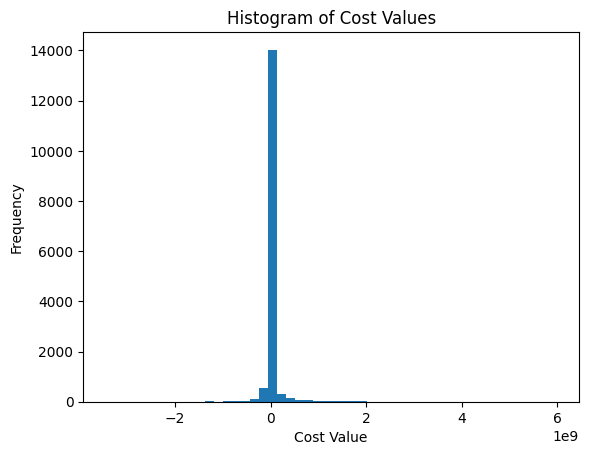

In [18]:
import matplotlib.pyplot as plt
plt.hist(results_all_pp.value, bins=50)
plt.title('Histogram of Cost Values')
plt.xlabel('Cost Value')
plt.ylabel('Frequency')
plt.show()

## Check for NaNs and Infs and DF Cleaning

In [19]:
# check nans
results_all_pp.value.isna().any()

np.False_

In [20]:
# check -inf or inf values
results_all_pp.value.isin([float('inf'), float('-inf')]).any()

np.False_

In [21]:
OUTPUT_CB_PATH

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/cost-benefits/out'

In [22]:
results_all_pp.to_csv(os.path.join(OUTPUT_CB_PATH, "cost_benefits_results.csv"), index=False)

## Reshape to load into tableau

In [23]:
# --- Read cost-benefit data ---
cb_data = results_all_pp.copy()

# Split 'variable' into components: name, sector, cb_type, item_1, item_2
# (Assumes exactly 5 colon-separated parts; if there are more colons inside the last field,
# they will be kept in item_2 thanks to n=4)
cb_chars = cb_data["variable"].astype(str).str.split(":", n=4, expand=True)
cb_chars.columns = ["name", "sector", "cb_type", "item_1", "item_2"]
cb_data = pd.concat([cb_data, cb_chars], axis=1)

In [24]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2
0,PFLO:UNCONDITIONAL,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
1,PFLO:UNCONDITIONAL,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
2,PFLO:UNCONDITIONAL,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
3,PFLO:UNCONDITIONAL,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
4,PFLO:UNCONDITIONAL,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices


In [25]:
# Scale value from USD to billions (divide by 1e9)
if "value" in cb_data.columns:
    cb_data["value"] = cb_data["value"] / 1e9

# --- Remove "shifted" entries ---
# Remove rows where item_2 contains "shifted"
cb_data = cb_data[~cb_data["item_2"].astype(str).str.contains("shifted", na=False)]

# Remove any remaining rows where variable contains "shifted2"
cb_data = cb_data[~cb_data["variable"].astype(str).str.contains("shifted2", na=False)]

# --- Add Year column (Year = time_period + 2015) ---
cb_data["Year"] = cb_data["time_period"] + 2015

**This Section Needs Manual Tunnning**

In [26]:
cb_data.strategy_code.unique()

array(['PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

In [27]:
# Harmonize strategy name changes with a single mapping (no duplicate replacements)
strategy_name_map = {
    "PFLO:BAU": "Business as Usual",
    "PFLO:UNCONDITIONAL": "Unconditional",
    "PFLO:CONDITIONAL": "Conditional",
}

cb_data["strategy"] = (
    cb_data["strategy_code"].astype(str).map(strategy_name_map).fillna(cb_data["strategy_code"])
)
print(cb_data["strategy"].unique())


['Unconditional' 'Conditional']


In [28]:
# --- Strategy ID mapping based on strategy_code ---
def map_strategy_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:BAU":
        return 6003
    if code == "PFLO:UNCONDITIONAL":
        return 6004
    if code == "PFLO:CONDITIONAL":
        return 6005
    return code  # keep original if not matched

cb_data["strategy_id"] = cb_data["strategy_code"].astype(str).map(map_strategy_id)

In [29]:
ssp_data.primary_id.unique()

array([    0, 75075, 76076])

In [30]:
ssp_data

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha,yf_lndu_supremum_pastures_tonne_per_ha
0,0,libya,8,0,7.870876e+05,0,577338.338326,0,149808.331157,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81
1,0,libya,9,0,7.999220e+05,0,583459.486527,0,152713.546004,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81
2,0,libya,10,0,8.118408e+05,0,592332.477155,0,155035.945235,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81
3,0,libya,11,0,8.239375e+05,0,601340.628569,0,157393.721185,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81
4,0,libya,12,0,8.362145e+05,0,610485.847634,0,159787.372955,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,76076,libya,31,0,1.140523e+06,0,836759.422473,0,219011.776326,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81
80,76076,libya,32,0,1.162134e+06,0,852740.687557,0,223194.681424,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81
81,76076,libya,33,0,1.185066e+06,0,869664.893207,0,227624.389943,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81
82,76076,libya,34,0,1.209597e+06,0,887723.423915,0,232350.994486,0,...,2,0.5,0,0,0.5,0,0,17,20,92.81


In [31]:
def map_primary_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:BAU":
        return 74074
    if code == "PFLO:UNCONDITIONAL":
        return 75075
    if code == "PFLO:CONDITIONAL":
        return 76076
    return code  # keep original if not matched

cb_data["primary_id"] = cb_data["strategy_code"].astype(str).map(map_primary_id)


**Manual Tunning Ends Here**

In [32]:
# --- Create ids (variable:strategy_id) ---
cb_data["ids"] = cb_data["variable"].astype(str) + ":" + cb_data["strategy_id"].astype(str)

In [33]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids
0,PFLO:UNCONDITIONAL,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2023.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...
1,PFLO:UNCONDITIONAL,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2024.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...
2,PFLO:UNCONDITIONAL,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2025.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...
3,PFLO:UNCONDITIONAL,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2026.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...
4,PFLO:UNCONDITIONAL,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2027.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...


In [34]:
cb_data.strategy.unique()

array(['Unconditional', 'Conditional'], dtype=object)

In [35]:
cb_data.strategy_code.unique()

array(['PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

In [36]:
# --- Read GDP and merge ---
# Keep only needed columns
gdp = ssp_data.loc[:, ["primary_id", "time_period", "gdp_mmm_usd"]]
gdp.head(100)

,primary_id,time_period,gdp_mmm_usd
0,0,8,101.162039
1,0,9,105.576742
2,0,10,107.688276
3,0,11,109.842042
4,0,12,112.038883
...,...,...,...
79,76076,31,163.219496
80,76076,32,166.483886
81,76076,33,169.813564
82,76076,34,173.209835


In [37]:
gdp[gdp['primary_id']== 76076]

,primary_id,time_period,gdp_mmm_usd
56,76076,8,101.162039
57,76076,9,105.576742
58,76076,10,107.688276
59,76076,11,109.842042
60,76076,12,112.038883
61,76076,13,114.279660
62,76076,14,116.565254
63,76076,15,118.896559
64,76076,16,121.274490
65,76076,17,123.699980


In [38]:
# Merge cb_data with gdp on primary_id and time_period
cb_data = cb_data.merge(gdp, on=["primary_id", "time_period"], how="left")
cb_data

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,...,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids,gdp_mmm_usd
0,PFLO:UNCONDITIONAL,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2023.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...,101.162039
1,PFLO:UNCONDITIONAL,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2024.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...,105.576742
2,PFLO:UNCONDITIONAL,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2025.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...,107.688276
3,PFLO:UNCONDITIONAL,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2026.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...,109.842042
4,PFLO:UNCONDITIONAL,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2027.0,Unconditional,6004,75075,cb:agrc:crop_value:crops_produced:bevs_and_spi...,112.038883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15563,PFLO:CONDITIONAL,0.0,libya,31.0,energy_consumption_inen_total,102.058984,61.470236,-40.588748,cb:inen:technical_savings:fuel_switch:lo_heat,0.003385,...,inen,technical_savings,fuel_switch,lo_heat,2046.0,Conditional,6005,76076,cb:inen:technical_savings:fuel_switch:lo_heat:...,163.219496
15564,PFLO:CONDITIONAL,0.0,libya,32.0,energy_consumption_inen_total,102.226990,61.022401,-41.204589,cb:inen:technical_savings:fuel_switch:lo_heat,0.003436,...,inen,technical_savings,fuel_switch,lo_heat,2047.0,Conditional,6005,76076,cb:inen:technical_savings:fuel_switch:lo_heat:...,166.483886
15565,PFLO:CONDITIONAL,0.0,libya,33.0,energy_consumption_inen_total,102.382759,60.681375,-41.701384,cb:inen:technical_savings:fuel_switch:lo_heat,0.003478,...,inen,technical_savings,fuel_switch,lo_heat,2048.0,Conditional,6005,76076,cb:inen:technical_savings:fuel_switch:lo_heat:...,169.813564
15566,PFLO:CONDITIONAL,0.0,libya,34.0,energy_consumption_inen_total,102.525273,60.444782,-42.080491,cb:inen:technical_savings:fuel_switch:lo_heat,0.003510,...,inen,technical_savings,fuel_switch,lo_heat,2049.0,Conditional,6005,76076,cb:inen:technical_savings:fuel_switch:lo_heat:...,173.209835


In [39]:
cb_data.isna().sum()

strategy_code                0
future_id                    0
region                       0
time_period                  0
difference_variable          0
variable_value_baseline      0
variable_value_pathway     168
difference_value             0
variable                     0
value                        0
name                         0
sector                       0
cb_type                      0
item_1                       0
item_2                     532
Year                         0
strategy                     0
strategy_id                  0
primary_id                   0
ids                          0
gdp_mmm_usd                  0
dtype: int64

## Save

In [40]:
cb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15568 entries, 0 to 15567
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   strategy_code            15568 non-null  object 
 1   future_id                15568 non-null  float64
 2   region                   15568 non-null  object 
 3   time_period              15568 non-null  float64
 4   difference_variable      15568 non-null  object 
 5   variable_value_baseline  15568 non-null  float64
 6   variable_value_pathway   15400 non-null  float64
 7   difference_value         15568 non-null  float64
 8   variable                 15568 non-null  object 
 9   value                    15568 non-null  float64
 10  name                     15568 non-null  object 
 11  sector                   15568 non-null  object 
 12  cb_type                  15568 non-null  object 
 13  item_1                   15568 non-null  object 
 14  item_2                

In [41]:
cb_data["Year"]

0        2023.0
1        2024.0
2        2025.0
3        2026.0
4        2027.0
          ...  
15563    2046.0
15564    2047.0
15565    2048.0
15566    2049.0
15567    2050.0
Name: Year, Length: 15568, dtype: float64

In [42]:
# Use .loc and avoid chained indexing; cast Year to int to be robust
selection = cb_data.loc[(cb_data["Year"] == 2027)]

In [43]:
cb_data.loc[
    (cb_data["variable"] == "cb:entc:technical_cost:electricity:capex") &
    (cb_data["value"] > 0),
    "value"
] = 0


In [44]:
# ensure no positive technical costs for electricity capex
mask = cb_data["variable"].astype(str).str.contains("cb:entc:technical_cost:electricity:capex", na=False)
cb_data.loc[mask, "value"] = -cb_data.loc[mask, "value"].abs()

# quick check
cb_data[mask]["value"].describe()

count    56.000000
mean     -0.962873
std       0.647172
min      -2.458133
25%      -1.362919
50%      -0.954913
75%      -0.487945
max      -0.000000
Name: value, dtype: float64

In [45]:
cb_data[cb_data.variable == "cb:entc:technical_cost:electricity:capex"].describe()


,future_id,time_period,variable_value_baseline,variable_value_pathway,difference_value,value,Year,strategy_id,primary_id,gdp_mmm_usd
count,56.0,56.00000,56.000000,56.000000,56.000000,56.000000,56.00000,56.000000,56.000000,56.000000
mean,0.0,21.50000,335.895442,1298.768419,962.872977,-0.962873,2036.50000,6004.500000,75575.500000,136.882164
std,0.0,8.15085,563.727021,775.713935,647.171788,0.647172,8.15085,0.504525,505.029504,22.184030
min,0.0,8.00000,0.000000,0.000000,0.000000,-2.458133,2023.00000,6004.000000,75075.000000,101.162039
25%,0.0,14.75000,187.288730,897.946520,487.944993,-1.362919,2029.75000,6004.000000,75075.000000,118.313732
50%,0.0,21.50000,214.435718,1293.993619,954.912868,-0.954913,2036.50000,6004.500000,75575.500000,135.235805
75%,0.0,28.25000,246.868907,1650.108861,1362.919273,-0.487945,2043.25000,6005.000000,76076.000000,154.574404
max,0.0,35.00000,2529.701885,2861.480772,2458.133330,-0.000000,2050.00000,6005.000000,76076.000000,176.674032


In [46]:
cb_data.to_csv(os.path.join(DIF_OUTPUT_FILE,"cb_data.csv"), index = False)

In [47]:
os.path.join(DIF_OUTPUT_FILE,"cb_data.csv")

'/Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/cb_data.csv'